<div style="font-family: system-ui, -apple-system, sans-serif; text-align: center; padding: 48px 24px 24px;">
    <div style="display: inline-block; background: #be0f05; color: white;
                padding: 12px 20px; border-radius: 12px; margin-bottom: 20px;">
        <span style="font-size: 34px; font-weight: 800; letter-spacing: -0.5px;">TIP4PATLIBS &ndash; Assemble the valuation</span>
    </div>
    <div style="font-size: 16px; color: #475569; margin-bottom: 8px; line-height: 1.6;">
        One patent, forty answers, one number &mdash; and an honest account of <strong>how much of that number is evidence</strong>.
    </div>
    <div style="font-size: 13px; color: #94a3b8; margin-bottom: 32px;">
        EPO Academy Training Material &nbsp;&middot;&nbsp; <a href="https://patentreports.depa.tech" target="_blank"
           style="color: #be0f05; text-decoration: none; font-weight: 600;">created by Arne Kr&uuml;ger</a>
        &nbsp;&middot;&nbsp; model: <strong>EPO IPScore 3.01</strong>
        &nbsp;&middot;&nbsp; scenario analysis after Riccardo Priore's NPV Target Planner
    </div>
    <div style="background: #f8fafc; border-radius: 12px; padding: 24px 28px; max-width: 680px;
                margin: 0 auto; border: 1px solid #e2e8f0; text-align: left;">
        <div style="font-size: 14px; color: #334155; line-height: 1.9;">
            <strong>What this notebook does</strong>
            <br/>Step&nbsp;1 &nbsp;&middot;&nbsp; The worked example: one patent, scored
            <br/>Step&nbsp;2 &nbsp;&middot;&nbsp; The company behind it: seven figures
            <br/>Step&nbsp;3 &nbsp;&middot;&nbsp; The profile &mdash; where this patent is strong and weak
            <br/>Step&nbsp;4 &nbsp;&middot;&nbsp; <strong>How much of this valuation can data reach?</strong>
            <br/>Step&nbsp;5 &nbsp;&middot;&nbsp; The eight answers that carry money
            <br/>Step&nbsp;6 &nbsp;&middot;&nbsp; The ten-year cash flow and the NPV
            <br/>Step&nbsp;7 &nbsp;&middot;&nbsp; Assemble the report &mdash; one HTML file, one workbook
            <br/>Step&nbsp;8 &nbsp;&middot;&nbsp; Open it
        </div>
    </div>
    <div style="background: #fdf2f2; border-radius: 10px; padding: 16px 24px; max-width: 680px;
                margin: 28px auto 0; border: 1px solid #fecaca;">
        <div style="font-size: 14px; color: #404955; font-weight: 600;">&#9654; &nbsp;Part 4 of 4 &mdash; run order is <strong>1 &rarr; 2 &rarr; 3 &rarr; 4</strong>.</div>
        <div style="font-size: 12px; color: #64748b; margin-top: 6px; line-height: 1.6;">
            This notebook assembles whatever the others have produced, and says which state it
            is in. Without notebook&nbsp;2 the answers are the adviser's first pass and the
            report reads <em>0&nbsp;measured</em>; without notebook&nbsp;3 it has one section
            fewer. Both are valid reports &mdash; they are just not the finished one.
            <br/>No PATSTAT, no database, no internet <em>here</em>. Notebook&nbsp;2 is the only
            one that needs <strong>EPO&nbsp;TIP</strong>.
        </div>
    </div>
</div>

---

## The report contract — what this notebook promises the other three

A landscape report is a pile of charts: module 6 could stitch its together in any order and it
still read well. **A valuation is not.** It has a required shape — you cannot show someone a
Net Present Value before you have shown them what was assumed to get there. So the contract
here is different from module 6's, deliberately:

**Notebook 4 always builds the spine itself.** Six sections, fixed order, always present:

| # | Section | Built from |
|---|---------|------------|
| 1 | The verdict — NPV, score, provenance split | the answer set + the company figures |
| 2 | The patent and the company | the worked example |
| 3 | The profile — strengths and weaknesses | `kit.profile()` |
| 4 | How much of this valuation can data reach? | `kit.PATSTAT_CANDIDATES` |
| 5 | The eight answers that carry money | `kit.oek_from_answers()` |
| 6 | The ten-year cash flow | `kit.cash_flow()` · `kit.npv()` |
| 7 | All forty answers, with provenance | `kit.answer_table()` |

**Notebooks 2 and 3 contribute two things, not sections.** Notebook 2 hands over *a better
answer set* — the same forty answers, but with `provenance="measured"` and a real PATSTAT fact
in `evidence` wherever a query decided the score. Notebook 3 hands over *one extra section*,
the sensitivity ranking. Neither reshapes the report; the spine above stays exactly as it is.

The machinery for that is `kit.record_section()` / `kit.load_sections()`, added at the moment a
second producer actually existed and not before. Notebook 3 writes its section into
`3_valuation_and_scenarios_output/_report_parts/`; the cell below picks up whatever it finds
and slots it in by `order`.

**So the run order matters:** `1 → 3 → 4` today, `1 → 2 → 3 → 4` once notebook 2 exists. Run
this notebook without having run notebook 3 and you get a perfectly good report with seven
sections instead of eight — it will tell you so in the output.

---

## Step 1 — The worked example: one patent, scored by hand

Every valuation starts with someone answering forty questions. Here is that answer set, for a
single patent family, filled in the way a PATLIB adviser would fill it in a first session with
a client.

> **This is a worked example.** The patent below stands in for a real family; decision **V5**
> in the rebuild plan says the final example comes from module 6's antibiotic-resistance
> corpus, and notebook 2 picks it when it first meets PATSTAT.

Two things about the scores you are looking at:

* **Every one of them is a judgement.** Nothing here has been checked against a database,
  because this notebook does not have one. So all forty answers carry `provenance="judgement"`
  — and the report will say `0 measured · 0 informed · 40 judgement` in large type on its front
  section. That is not a placeholder we forgot to fill; it is what an IPScore valuation
  actually looks like today, in module 7 and everywhere else.
* **Eleven of them are marked as reachable.** `kit.PATSTAT_CANDIDATES` lists the questions a
  query can speak to and what it would source for each. We attach that to the answer's
  `evidence` field as a promise rather than a fact — the wording starts with `-> notebook 2:`
  so nobody can mistake it for something that was measured.

And one thing you should know about how these particular numbers were picked. The eight
money-carrying answers (B5, C2, C3, C6, D1–D4) were **chosen so that the cash-flow chart in
step 6 teaches well**: the technology reaches the market early enough and lives long enough to
fill the ten-year horizon, and all six cash-flow components are non-zero rather than two of
them sitting dead in the legend. They are plausible for this kind of invention, but they were
selected for legibility, not sampled from a real patent. When notebook 2 settles **V5** and a
real family arrives, expect a less tidy picture — that is what a real one looks like.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go

import ipscore_kit as kit

spec = kit.load_spec()

# The patent, the company figures and the forty scores all live in worked_example.json.
# Notebook 3 reads the same file, so the two cannot drift - and swapping in a real family
# later (decision V5) is an edit to that one file.
example = kit.load_worked_example()
PATENT = example["patent"]
scores = example["scores"]

# The best answer set available: notebook 2's measured set once it has run on TIP, otherwise
# the adviser's first pass. `source` says which, and the report prints it - a reader has to be
# able to tell a measured valuation from a structured opinion at a glance.
answers, source = kit.load_answers()

assert len(answers) == len(spec.questions), "the questionnaire needs all 40 answers"
print(f"answer set: {source}")
print()
print(PATENT["title"])
print(f"  {PATENT['applicant']} - {PATENT['field']}\n")
print(f"{len(answers)} answers  -  "
      f"{sum(1 for a in answers.values() if a.provenance == 'measured')} measured, "
      f"{sum(1 for a in answers.values() if a.provenance == 'informed')} informed, "
      f"{sum(1 for a in answers.values() if a.provenance == 'judgement')} judgement")
print(f"{len(kit.PATSTAT_CANDIDATES)} of them are marked as reachable by a PATSTAT query.")

answer set: measured against PATSTAT for EP3074539B1 by 2_evidence_from_patstat.ipynb

Method for detecting and characterising a microorganism
  Q-Linea AB, Uppsala (SE) - in-vitro diagnostics / antimicrobial resistance

40 answers  -  2 measured, 6 informed, 32 judgement
11 of them are marked as reachable by a PATSTAT query.


---

## Step 2 — The company behind the patent: seven figures

The questionnaire alone cannot produce money. A patent is worth something *to somebody* — the
same invention is worth more inside a company with a large turnover in the relevant business
area than inside a small one. So the model needs seven figures straight from the accounts.

These are the same figures notebook 1 used, so the two notebooks tell one story.

In [2]:
company = example["financials"]

facts = pd.DataFrame([
    {"Figure": "Business turnover", "Value": f"{company.turnover:,.0f} EUR"},
    {"Figure": "Direct costs", "Value": f"{company.direct_costs:,.0f} EUR"},
    {"Figure": "Indirect costs", "Value": f"{company.indirect_costs:,.0f} EUR"},
    {"Figure": "Depreciation", "Value": f"{company.depreciation:,.0f} EUR"},
    {"Figure": "Depreciation period", "Value": f"{company.depreciation_period:.0f} years"},
    {"Figure": "Share of turnover in this business area", "Value": f"{company.business_area_share:.0%}"},
    {"Figure": "Discount rate", "Value": f"{company.discount_rate:.0%}"},
    {"Figure": "-> cost share (derived)", "Value": f"{company.cost_share:.0%} of turnover"},
    {"Figure": "-> investment index (derived)", "Value": f"{company.investment_index:.2f}"},
])
facts

,Figure,Value
0,Business turnover,"150,000 EUR"
1,Direct costs,"90,000 EUR"
2,Indirect costs,"22,500 EUR"
3,Depreciation,"4,500 EUR"
4,Depreciation period,7 years
5,Share of turnover in this business area,40%
6,Discount rate,12%
7,-> cost share (derived),75% of turnover
8,-> investment index (derived),0.21


---

## Step 3 — The profile: where this patent is strong, and where it is weak

The first read-out uses **all forty** answers. Each section scores points out of its own
maximum, and the shape that comes out is the qualitative verdict: a patent can be legally
solid and commercially thin, or the other way round, and the radar shows which.

This is also the half of IPScore that never touches the money — and it is the half most
clients find immediately useful, because it points at *what to fix*.

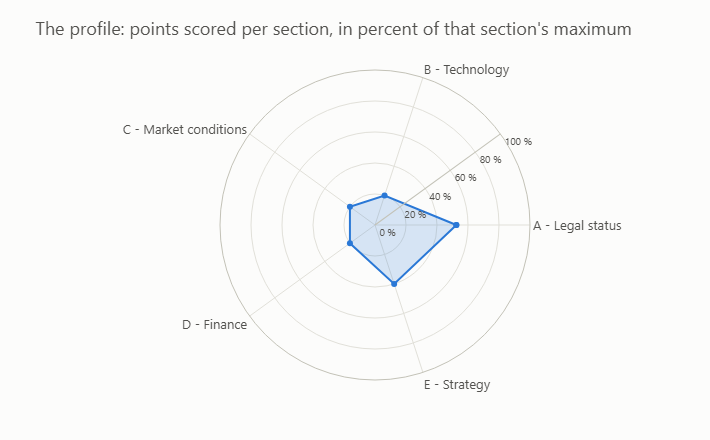

Total  61 / 200 points
Average risk         -0.88   (0 = no weakness, -1 = worst on every risk driver)
Average opportunity  +0.12   (0 = no upside, +1 = best on every opportunity driver)


In [3]:
prof = kit.profile(answers, spec)

section_max = {key: 5 * len(spec.of_section(key)) for key in spec.sections}
radar = pd.DataFrame([
    {
        "Section": f"{key} - {title}",
        "Points": prof.section_points[key],
        "Maximum": section_max[key],
        "Percent": prof.section_points[key] / section_max[key] * 100,
    }
    for key, title in spec.sections.items()
])

fig_profile = go.Figure()
fig_profile.add_trace(go.Scatterpolar(
    r=list(radar["Percent"]) + [radar["Percent"].iloc[0]],
    theta=list(radar["Section"]) + [radar["Section"].iloc[0]],
    fill="toself", name="This patent",
    line={"color": kit.PALETTE["revenue"], "width": 2},
    fillcolor="rgba(42,120,214,0.18)",
    hovertemplate="%{theta}<br>%{r:.0f} % of the section maximum<extra></extra>",
))
fig_profile.update_layout(
    **kit.CHART_LAYOUT, height=440, showlegend=False,
    title="The profile: points scored per section, in percent of that section's maximum",
    polar={
        "bgcolor": kit.PALETTE["surface"],
        "radialaxis": {"visible": True, "range": [0, 100], "angle": 36, "tickangle": 36,
                       "gridcolor": kit.PALETTE["grid"], "linecolor": kit.PALETTE["axis"],
                       "ticksuffix": " %", "tickfont": {"size": 10}},
        "angularaxis": {"gridcolor": kit.PALETTE["grid"], "linecolor": kit.PALETTE["axis"]},
    },
)
fig_profile.show()

print(f"Total  {prof.total_points} / {prof.max_points} points")
print(f"Average risk         {prof.average_risk:+.2f}   (0 = no weakness, -1 = worst on every risk driver)")
print(f"Average opportunity  {prof.average_opportunity:+.2f}   (0 = no upside, +1 = best on every opportunity driver)")

---

## Step 4 — How much of this valuation can data reach?

This is the question module 8 exists to ask, and the honest answer is *less than you would
hope*. Of the forty questions, **eleven** can be spoken to by a PATSTAT query, and they are not
equal:

* **strong** — the answer is a matter of record. Is the patent granted? When was it filed?
  Which offices is the family in? A query decides it; nobody's opinion is involved.
* **good** — the query yields a genuine new insight, but a person still picks the level.
  Whether this filing consolidates existing markets or opens new ones is visible in the data;
  what counts as "new" is not.
* **proxy** — the number correlates with the question without answering it. Claim *count* is
  not claim *breadth*; forward citations measure attention, not technical superiority. Shown,
  and labelled, and never silently used as an answer.
* **context** — informs the answer without narrowing it.

The remaining **twenty-nine questions are expert judgement and nothing else**. Any tool that
does not tell you that is selling you a false precision.

And one thing this chart cannot show, which notebook 2 makes unavoidable: **none of these eleven
questions is one of the eight that carry money.** Everything data can reach here shapes the
profile and the legal picture. The Net Present Value is decided entirely by answers no query can
check.

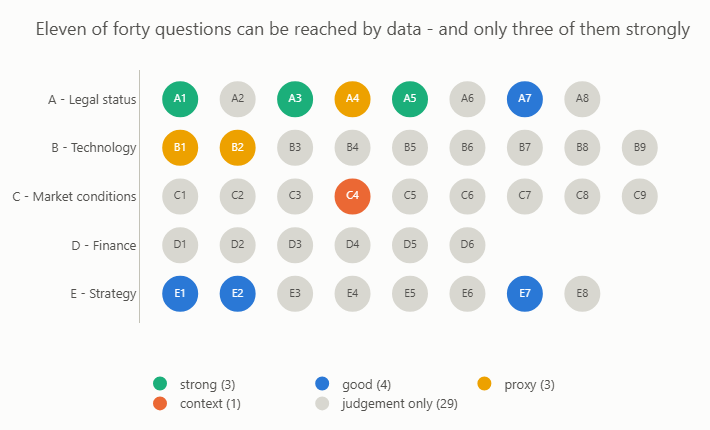

reach
strong             3
good               4
proxy              3
context            1
judgement only    29


In [4]:
REACH_ORDER = ["strong", "good", "proxy", "context", "judgement only"]
REACH_COLOR = {
    "strong": kit.PALETTE["efficiency"],
    "good": kit.PALETTE["revenue"],
    "proxy": kit.PALETTE["investment_reduction"],
    "context": kit.PALETTE["regained"],
    "judgement only": kit.PALETTE["inactive"],
}

table = pd.DataFrame(kit.answer_table(answers, spec))
table["reach"] = table["patstat_strength"].replace("", "judgement only")

section_keys = list(spec.sections)
grid = table.assign(
    x=table["id"].str[1:].astype(int),
    y=[len(section_keys) - section_keys.index(s) for s in table["section"]],
)

fig_reach = go.Figure()
for reach in REACH_ORDER:
    part = grid[grid["reach"] == reach]
    if part.empty:
        continue
    fig_reach.add_trace(go.Scatter(
        x=part["x"], y=part["y"], mode="markers+text",
        name=f"{reach} ({len(part)})",
        marker={"size": 38, "color": REACH_COLOR[reach],
                "line": {"width": 2, "color": kit.PALETTE["surface"]}},
        text=part["id"], textposition="middle center",
        textfont={"size": 11,
                  "color": kit.PALETTE["ink_secondary"] if reach == "judgement only" else "white"},
        customdata=part[["factor", "patstat_sources"]],
        hovertemplate="<b>%{text}</b> - %{customdata[0]}<br>%{customdata[1]}<extra></extra>",
    ))

fig_reach.update_layout(
    **kit.CHART_LAYOUT, height=430,
    title="Eleven of forty questions can be reached by data - and only three of them strongly",
)
fig_reach.update_xaxes(visible=False, range=[0.3, 9.7])
fig_reach.update_yaxes(
    tickmode="array",
    tickvals=[len(section_keys) - i for i in range(len(section_keys))],
    ticktext=[f"{k} - {v}" for k, v in spec.sections.items()],
    range=[0.4, len(section_keys) + 0.6], showgrid=False,
)
fig_reach.show()

reach_counts = table["reach"].value_counts().reindex(REACH_ORDER).dropna().astype(int)
print(reach_counts.to_string())

---

## Step 5 — The eight answers that carry money

Here is the single most surprising fact in IPScore, and the one worth putting on a slide:
**thirty-two of the forty questions never touch the Net Present Value.** They shape the
profile, they inform the conversation — and then the model drops them.

Eight questions carry money. Each maps its 1–5 answer onto one economic parameter through a
fixed table taken from the EPO workbook. Change any other answer and the NPV does not move by
a single cent.

In [5]:
oek = kit.oek_from_answers(answers, spec)

money = pd.DataFrame([
    {
        "Question": q.id,
        "What it asks": q.factor,
        "Answer given": f"{scores[q.id]} - {q.answers[scores[q.id] - 1]}",
        "Parameter": q.oek_param,
        "Value": q.value_for(scores[q.id]),
        "Range across the 5 answers": f"{min(q.oek_values):g} ... {max(q.oek_values):g}",
    }
    for q in spec.oek_questions
])
money

,Question,What it asks,Answer given,Parameter,Value,Range across the 5 answers
0,B5,Pre-commercial term of development,1 - 5 years before commercialisation,years_to_market,5.000,0 ... 5
1,C2,Market growth rate,1 - Very low (½%),market_growth,0.005,0.005 ... 0.15
2,C3,Life expectancy,1 - ½ year,life_expectancy,0.500,0.5 ... 8
3,C6,Potential extra turnover,1 - Very small extra turnover in the business ...,extra_turnover_share,0.005,0.005 ... 0.1
4,D1,Business output maintainability,1 - 100% of business output can be maintained ...,output_maintainable,1.000,0 ... 1
5,D2,Future cost of development,1 - Extremely high investment (30% of business...,development_cost_share,0.300,0.005 ... 0.3
6,D3,Cost of production,1 - 30% increase due to use of the patented te...,production_cost_index,1.300,0.7 ... 1.3
7,D4,Investment intensity,1 - 120% of present investment intensity,investment_index,1.200,0.5 ... 1.2


---

## Step 6 — The ten-year cash flow, and the number at the end

Those eight parameters plus the seven company figures drive a ten-year cash flow. Each year
adds up six components — the patent's own revenue, the revenue it *keeps* from being copied,
the efficiency it buys, and the investment it saves, minus costs and minus the one-time
investment it demands. The sum, discounted back to today, is the NPV.

Two invariants the workbook is easy to get wrong on, both asserted by the acceptance test in
notebook 1: **investments are a one-time event** in the launch year, not an annual charge, and
**entry and exit years are fractional** — reaching the market after 2.5 years earns half a
year of revenue in year 3.

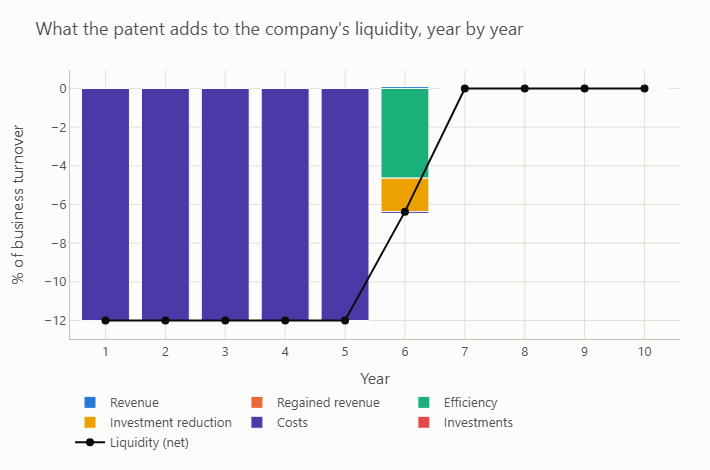

Net Present Value   -69,726 EUR
Score               61 / 200 points
Provenance          2 measured - 6 informed - 32 judgement


In [6]:
flow = kit.cash_flow(company, oek)
value = kit.npv(company, oek)

components = [
    ("Revenue", [r.revenue for r in flow], kit.PALETTE["revenue"]),
    ("Regained revenue", [r.regained_revenue for r in flow], kit.PALETTE["regained"]),
    ("Efficiency", [r.efficiency for r in flow], kit.PALETTE["efficiency"]),
    ("Investment reduction", [r.investment_reduction for r in flow], kit.PALETTE["investment_reduction"]),
    ("Costs", [-r.costs for r in flow], kit.PALETTE["costs"]),
    ("Investments", [-r.investments for r in flow], kit.PALETTE["investments"]),
]
years = [r.year for r in flow]

fig_flow = go.Figure()
for name, values, color in components:
    fig_flow.add_trace(go.Bar(
        x=years, y=values, name=name,
        marker={"color": color, "line": {"width": 1, "color": kit.PALETTE["surface"]}},
        hovertemplate="%{y:.2f} % of turnover<extra>" + name + "</extra>",
    ))
fig_flow.add_trace(go.Scatter(
    x=years, y=[r.liquidity for r in flow], name="Liquidity (net)",
    mode="lines+markers", line={"color": kit.PALETTE["ink"], "width": 2},
    marker={"size": 8}, hovertemplate="%{y:.2f} % of turnover<extra>Liquidity</extra>",
))
fig_flow.update_layout(
    **kit.CHART_LAYOUT, barmode="relative", height=470, hovermode="x unified",
    title="What the patent adds to the company's liquidity, year by year",
)
fig_flow.update_xaxes(title="Year", dtick=1)
fig_flow.update_yaxes(title="% of business turnover")
fig_flow.show()

cash = pd.DataFrame([{
    "Year": r.year,
    "On market": f"{r.active_fraction:.2f}",
    "Revenue": r.revenue,
    "Regained": r.regained_revenue,
    "Efficiency": r.efficiency,
    "Inv. reduction": r.investment_reduction,
    "Costs": -r.costs,
    "Investments": -r.investments,
    "Liquidity": r.liquidity,
    "Discounted EUR": r.discounted,
} for r in flow])

print(f"Net Present Value   {value:,.0f} EUR")
print(f"Score               {prof.total_points} / {prof.max_points} points")
print(f"Provenance          {prof.provenance_counts['measured']} measured - "
      f"{prof.provenance_counts['informed']} informed - "
      f"{prof.provenance_counts['judgement']} judgement")

---

## Step 7 — Assemble the report

Everything above becomes **one self-contained HTML file**. Three constraints decide how, and
all three were learned the hard way in module 6:

* **One embedded copy of `plotly.js`, and no external requests.** The report has to work on a
  laptop with no internet, in a room with bad wifi.
* **No iframes, anywhere.** Jupyter serves `/files/` under a CSP sandbox that disables
  JavaScript, so an iframed chart renders as a blank rectangle inside TIP. Every figure goes in
  as an inline `<div>`.
* **The assembly stays in this notebook**, not in an external script. That was the original
  defect in the material we started from: a report nobody could regenerate because the step
  that built it had never been committed.

The report is one page with a section nav — a valuation is read top to bottom, so unlike
module 6's landscape report there is no paged mode to switch to.

In [7]:
from plotly.offline import get_plotlyjs

TOOL_DIR = Path.cwd() / "4_tool"
TOOL_DIR.mkdir(exist_ok=True)
report_path = TOOL_DIR / "ipscore_valuation.html"

PROV_COLOR = {"measured": kit.PALETTE["efficiency"],
              "informed": kit.PALETTE["revenue"],
              "judgement": kit.PALETTE["ink_muted"]}


def esc(text):
    return (str(text).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;"))


def simple_table(df, align_right=()):
    """A dataframe as a plain report table."""
    head = "".join(f"<th>{esc(c)}</th>" for c in df.columns)
    rows = []
    for _, r in df.iterrows():
        cells = "".join(
            f'<td class="{"num" if c in align_right else ""}">'
            f'{esc(f"{r[c]:,.2f}") if isinstance(r[c], float) else esc(r[c])}</td>'
            for c in df.columns)
        rows.append(f"<tr>{cells}</tr>")
    return f'<table class="t"><thead><tr>{head}</tr></thead><tbody>{"".join(rows)}</tbody></table>'


def answers_table(rows):
    """The forty answers, with a provenance badge and the money flag on every line."""
    out = []
    current = None
    for r in rows:
        if r["section"] != current:
            current = r["section"]
            out.append(f'<tr class="sec"><td colspan="6">{esc(r["section"])} &middot; '
                       f'{esc(r["section_title"])}</td></tr>')
        badge = (f'<span class="badge" style="background:{PROV_COLOR[r["provenance"]]}">'
                 f'{esc(r["provenance"])}</span>')
        money = (f'<span class="money" title="{esc(r["oek_param"])} = {r["oek_value"]:g}">'
                 f'&euro;</span>') if r["carries_money"] else ""
        reach = (f'<span class="reach r-{r["patstat_strength"]}">{esc(r["patstat_strength"])}</span>'
                 if r["patstat_strength"] else "")
        note = f'<div class="ev">{esc(r["evidence"])}</div>' if r["evidence"] else ""
        out.append(
            f'<tr><td class="qid">{esc(r["id"])}{money}</td>'
            f'<td class="q">{esc(r["factor"])}{note}</td>'
            f'<td class="num">{r["score"]}</td>'
            f'<td class="ans">{esc(r["answer"])}</td>'
            f'<td>{badge}</td><td>{reach}</td></tr>')
    return ('<table class="t answers"><thead><tr><th>#</th><th>What it asks</th>'
            '<th>Score</th><th>Answer given</th><th>Provenance</th><th>Data reach</th>'
            f'</tr></thead><tbody>{"".join(out)}</tbody></table>')


def figure_html(fig, slug):
    return fig.to_html(full_html=False, include_plotlyjs=False,
                       div_id=f"fig_{slug}", default_width="100%")


# ---- the verdict panel -------------------------------------------------------------
pc = prof.provenance_counts
verdict = f"""
<div class="verdict">
  <div class="v-main">
    <div class="v-label">Net Present Value of the patented technology</div>
    <div class="v-number">{value:,.0f} <span class="cur">EUR</span></div>
    <div class="v-sub">over ten years, discounted at {company.discount_rate:.0%}</div>
  </div>
  <div class="v-side">
    <div class="v-box"><b>{prof.total_points}</b> / {prof.max_points}<span>IPScore points</span></div>
    <div class="v-box"><b>{prof.average_risk:+.2f}</b><span>average risk</span></div>
    <div class="v-box"><b>{prof.average_opportunity:+.2f}</b><span>average opportunity</span></div>
  </div>
</div>
<div class="prov">
  <div class="prov-title">How much of this number is evidence?</div>
  <div class="prov-row">
    <div class="prov-cell"><b style="color:{PROV_COLOR['measured']}">{pc['measured']}</b>
      <span>measured &mdash; a PATSTAT fact decided it</span></div>
    <div class="prov-cell"><b style="color:{PROV_COLOR['informed']}">{pc['informed']}</b>
      <span>informed &mdash; data narrowed it, a person chose</span></div>
    <div class="prov-cell"><b style="color:{PROV_COLOR['judgement']}">{pc['judgement']}</b>
      <span>judgement &mdash; expert opinion, nothing else</span></div>
  </div>
  <p class="prov-note"><b>Answer set:</b> {esc(source)}.
  Eleven of the forty questions are reachable by a PATSTAT query &mdash; three strongly &mdash;
  and notebook&nbsp;2 is what turns those into facts. <b>None of the eleven is one of the eight
  that carry money</b>, so measuring them sharpens the picture of the patent without moving this
  number by a cent. Read a valuation whose answers are judgement as a structured opinion, not as
  a measurement.</p>
</div>"""

# The spine: seven sections notebook 4 always builds itself, in a fixed order.
SPINE = [
    (100, "verdict", "The verdict", None, verdict),
    (200, "subject", "The patent and the company",
     "The patent is real and public. The company figures are not - see the warning below.",
     simple_table(pd.DataFrame([{"Field": k.replace("_", " ").title(), "Value": v}
                                for k, v in PATENT.items()]))
     + f'<div class="warn"><b>Illustrative financial figures.</b> {esc(example["financials_note"])}</div>'
     + simple_table(facts)),
    (300, "profile", "The profile",
     "All forty answers feed this. It says where the patent is strong - and what to fix.",
     figure_html(fig_profile, "profile")),
    (400, "reach", "How much of this valuation can data reach?",
     "Eleven of forty questions can be spoken to by a PATSTAT query. Twenty-nine cannot.",
     figure_html(fig_reach, "reach")),
    (500, "money", "The eight answers that carry money",
     "Change any of the other thirty-two and the NPV does not move by a cent.",
     simple_table(money, align_right=("Value",))),
    (600, "cashflow", "The ten-year cash flow",
     "Percent of business turnover per year; the discounted column is euros.",
     figure_html(fig_flow, "cashflow") + simple_table(
         cash, align_right=("Revenue", "Regained", "Efficiency", "Inv. reduction",
                            "Costs", "Investments", "Liquidity", "Discounted EUR"))),
    (900, "answers", "All forty answers",
     "The full questionnaire, with where every answer came from.",
     answers_table(kit.answer_table(answers, spec))),
]

# Optional sections other notebooks contributed. Notebook 3's sensitivity lands at 700 -
# after the cash flow, before the full questionnaire. An empty list is the normal state
# until notebook 3 has been run, and the report simply has one section fewer.
contributed = kit.load_sections()
SECTIONS = sorted(
    SPINE + [(e["order"], e["slug"], e["title"], e.get("note"),
              Path(e["fragment_path"]).read_text(encoding="utf-8")) for e in contributed],
    key=lambda row: row[0],
)

if contributed:
    print(f"{len(contributed)} contributed section(s): "
          + ", ".join(f"{e['order']} {e['title']}" for e in contributed))
else:
    print("No contributed sections - run 3_valuation_and_scenarios.ipynb to add the "
          "sensitivity analysis, then re-run this notebook.")

nav = "".join(f'<a href="#{slug}">{esc(t)}</a>' for _, slug, t, _, _ in SECTIONS)
body = "".join(
    f'<section id="{slug}"><h2>{esc(t)}</h2>'
    + (f'<p class="note">{esc(n)}</p>' if n else "")
    + f'<div class="content">{h}</div></section>'
    for _, slug, t, n, h in SECTIONS)

# Placeholders rather than an f-string: plotly.js and the fragments are full of braces.
TEMPLATE = r"""<!doctype html>
<html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>IPScore valuation &mdash; @@TITLE@@</title>
<script>@@PLOTLYJS@@</script>
<style>
  :root { --accent:#be0f05; --ink:#0b0b0b; --ink2:#52514e; --muted:#898781;
          --line:#e1e0d9; --bg:#fff; --panel:#fcfcfb; }
  @media (prefers-color-scheme: dark) {
    :root { --ink:#e8e6e1; --ink2:#b8b6b0; --muted:#8b8985; --line:#33322e;
            --bg:#141412; --panel:#1c1b19; }
  }
  * { box-sizing:border-box; }
  body { margin:0; font-family:system-ui,-apple-system,sans-serif; color:var(--ink);
         background:var(--bg); line-height:1.55; }
  header { padding:34px 24px 20px; text-align:center; border-bottom:1px solid var(--line); }
  .brand { display:inline-block; background:var(--accent); color:#fff; padding:9px 17px;
           border-radius:10px; font-weight:800; letter-spacing:-.3px; font-size:21px; }
  .sub { color:var(--muted); font-size:13px; margin-top:12px; }
  nav { position:sticky; top:0; z-index:20; display:flex; flex-wrap:wrap; gap:4px;
        justify-content:center; padding:10px 16px; background:var(--panel);
        border-bottom:1px solid var(--line); }
  nav a { color:var(--ink2); text-decoration:none; font-size:12.5px; font-weight:600;
          padding:5px 10px; border-radius:6px; border:1px solid transparent; }
  nav a:hover { color:var(--accent); border-color:var(--line); }
  main { max-width:1040px; margin:0 auto; padding:8px 24px 48px; }
  section { padding:30px 0; border-bottom:1px solid var(--line); scroll-margin-top:64px; }
  section:last-child { border-bottom:0; }
  h2 { font-size:21px; margin:0 0 4px; letter-spacing:-.2px; }
  .note { color:var(--muted); font-size:13px; margin:0 0 16px; }
  .content { width:100%; overflow-x:auto; }
  /* verdict */
  .verdict { display:flex; flex-wrap:wrap; gap:20px; align-items:stretch; }
  .v-main { flex:1 1 340px; background:var(--panel); border:1px solid var(--line);
            border-radius:14px; padding:24px 26px; }
  .v-label { font-size:13px; color:var(--muted); }
  .v-number { font-size:44px; font-weight:800; letter-spacing:-1.5px; color:var(--accent);
              line-height:1.15; margin:6px 0 2px; }
  .v-number .cur { font-size:20px; font-weight:700; color:var(--ink2); letter-spacing:0; }
  .v-sub { font-size:13px; color:var(--muted); }
  .v-side { flex:1 1 240px; display:flex; flex-direction:column; gap:10px; }
  .v-box { background:var(--panel); border:1px solid var(--line); border-radius:12px;
           padding:12px 16px; display:flex; align-items:baseline; gap:10px; }
  .v-box b { font-size:22px; font-weight:800; letter-spacing:-.5px; }
  .v-box span { font-size:12.5px; color:var(--muted); }
  .prov { margin-top:22px; border:1px solid var(--line); border-radius:14px; padding:20px 24px; }
  .prov-title { font-weight:700; font-size:15px; margin-bottom:14px; }
  .prov-row { display:flex; flex-wrap:wrap; gap:14px; }
  .prov-cell { flex:1 1 190px; display:flex; align-items:baseline; gap:9px; }
  .prov-cell b { font-size:26px; font-weight:800; letter-spacing:-.5px; }
  .prov-cell span { font-size:12.5px; color:var(--muted); }
  .prov-note { font-size:13.5px; color:var(--ink2); margin:16px 0 0; }
  /* tables */
  table.t { border-collapse:collapse; width:100%; font-size:13px; margin:0 0 18px; }
  table.t th { text-align:left; font-weight:700; font-size:12px; text-transform:uppercase;
               letter-spacing:.4px; color:var(--muted); border-bottom:2px solid var(--line);
               padding:8px 10px; white-space:nowrap; }
  table.t td { border-bottom:1px solid var(--line); padding:7px 10px; vertical-align:top; }
  table.t td.num { text-align:right; font-variant-numeric:tabular-nums; white-space:nowrap; }
  tr.sec td { background:var(--panel); font-weight:700; font-size:12px; letter-spacing:.4px;
              text-transform:uppercase; color:var(--ink2); }
  td.qid { font-weight:700; white-space:nowrap; }
  td.q { max-width:290px; }
  td.ans { color:var(--ink2); max-width:280px; }
  .ev { font-size:11.5px; color:var(--muted); margin-top:3px; font-style:italic; }
  .badge { display:inline-block; color:#fff; font-size:10.5px; font-weight:700; padding:2px 8px;
           border-radius:20px; text-transform:uppercase; letter-spacing:.3px; }
  .money { display:inline-block; margin-left:6px; background:#2a78d6; color:#fff; font-size:10px;
           font-weight:700; padding:1px 6px; border-radius:10px; }
  .reach { font-size:11px; font-weight:700; text-transform:uppercase; letter-spacing:.3px; }
  .r-strong { color:#1baf7a; } .r-good { color:#2a78d6; } .r-proxy { color:#eda100; }
  .r-context { color:#eb6834; } .r-open { color:#898781; }
  .warn { border-left:4px solid var(--accent); background:var(--panel); padding:12px 16px;
          border-radius:0 8px 8px 0; font-size:13px; margin:0 0 18px; color:var(--ink2); }
  footer { text-align:center; color:var(--muted); font-size:12px; padding:26px 24px 40px;
           border-top:1px solid var(--line); }
</style></head>
<body>
<header>
  <div class="brand">TIP4PATLIBS &mdash; What is this patent worth?</div>
  <div class="sub">@@TITLE@@ &middot; valued with the <b>EPO IPScore 3.01</b> model &middot;
     engine verified against the EPO workbook's three test patents</div>
</header>
<nav>@@NAV@@</nav>
<main>@@BODY@@</main>
<footer>
  Generated by <code>4_assemble_tool.ipynb</code> &middot; module 8 of TIP4PATLIBS &middot;
  created by Arne Kr&uuml;ger.<br>
  The model is <b>EPO IPScore 3.01</b>, an EPO tool; this is an independent implementation of it.
  The scenario analysis follows Riccardo Priore's NPV Target Planner.<br>
  Self-contained &mdash; no internet needed. @@COUNT@@ sections.
</footer>
</body></html>"""

html = (TEMPLATE
        .replace("@@PLOTLYJS@@", get_plotlyjs())
        .replace("@@TITLE@@", esc(PATENT["title"]))
        .replace("@@NAV@@", nav)
        .replace("@@BODY@@", body)
        .replace("@@COUNT@@", str(len(SECTIONS))))

report_path.write_text(html, encoding="utf-8")
print(f"Wrote {report_path.name}  -  {report_path.stat().st_size / 1e6:.1f} MB, "
      f"{len(SECTIONS)} sections, {html.count('plotly-graph-div')} inline charts, "
      f"{html.count('<iframe')} iframes.")

2 contributed section(s): 450 What the record actually says, 700 Which lever actually moves the number?
Wrote ipscore_valuation.html  -  4.7 MB, 9 sections, 6 inline charts, 0 iframes.


Wrote ipscore_valuation.html  -  4.7 MB, 8 sections, 5 inline charts, 0 iframes.


---

## Step 8 — The data workbook

The report is the argument; the workbook is the evidence. One sheet per step, so anyone can
check the arithmetic — or reuse the numbers — without opening a notebook or touching TIP.

This is what makes a valuation auditable. The number at the top of the report is only as good
as the forty answers under it, and the workbook is where those answers sit in the open.

In [8]:
import json

data_path = TOOL_DIR / "ipscore_valuation_data.xlsx"

sheets = {
    "1 patent and company": pd.concat([
        pd.DataFrame([{"Field": k.title(), "Value": v} for k, v in PATENT.items()]),
        facts.rename(columns={"Figure": "Field"}),
    ], ignore_index=True),
    "2 all forty answers": pd.DataFrame(kit.answer_table(answers, spec)),
    "3 profile": radar,
    "4 money parameters": money,
    "5 cash flow": cash,
}

# Whatever the contributed sections brought with them, one sheet each.
for entry in contributed:
    for label, path in entry["sheet_paths"].items():
        sheets[f"6 {label}"[:31]] = pd.DataFrame(json.loads(Path(path).read_text(encoding="utf-8")))

with pd.ExcelWriter(data_path, engine="openpyxl") as writer:
    for name, df in sheets.items():
        df.to_excel(writer, sheet_name=name[:31], index=False)

print(f"Wrote {data_path.name}  -  {len(sheets)} sheets: {', '.join(sheets)}")

Wrote ipscore_valuation_data.xlsx  -  7 sheets: 1 patent and company, 2 all forty answers, 3 profile, 4 money parameters, 5 cash flow, 6 evidence, 6 sensitivity


---

## Step 9 — Open the valuation

The report is self-contained HTML, so it opens with the course's shared `open_html` helper: it
serves the file through jupyter-server-proxy and shows a red **Open** button, with a download
link beside it. That is the reliable route inside TIP — a plain link or an iframe hits
Jupyter's sandbox and renders nothing.

In [9]:
root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "CLAUDE.md").exists()), Path.cwd())
sys.path.insert(0, str(root / "1_startwithtip"))
from tip_tools import open_html

open_html(report_path, "the IPScore valuation")

---

## Done — and what this proved

The chain exists end to end: **forty answers → a score, a profile and an NPV → one
self-contained report and one workbook**, opened inside TIP. It is deliberately small. That is
the point of building the last step first — the shape of the deliverable is now fixed, and the
two notebooks still missing can be written against something real instead of against a plan.

**What is still missing, in order:**

| Notebook | What it adds | Needs |
|---|---|---|
| `2_evidence_from_patstat.ipynb` | replaces the eleven judgement answers with PATSTAT facts, so the provenance panel above stops reading `0 measured` | **TIP** |
| `3_valuation_and_scenarios.ipynb` | one extra section: which of the eight levers moves the NPV most | nothing |

And two things a reader should hold on to:

* **The number is a structured opinion.** Forty subjective answers went in; the arithmetic in
  between is exact and verified against the EPO's own workbook, but exact arithmetic over
  opinions does not produce a fact. The provenance panel exists so nobody forgets that.
* **Only eight of the forty answers can move it.** If a client wants a different number, there
  are exactly eight places to argue — and notebook 3 will rank them.